# AE370 Group Project Two 
*Author: Jack Dean - jedean2@illinois.edu*

### Problem
**Ask: Use either a Finite diffrence of Finite Element method to model the following canotical expression**
$$\frac{\partial ^2 u}{\partial t^2} = c^2 \frac{\partial^2 u}{\partial x^2},~~~~~x\in[a,b], ~~~t \in [0,t]$$


### Modification and Definitions
For a guitar string, we will modify the canotical wavefunction to better represent our system. Otherwise known as the telegraph equation.

$$\rho A \frac{\partial^2 u}{\partial t^2} +c_d \frac{\partial u}{\partial t}- T \frac{\partial^2 u}{\partial x^2} = 0$$
where
- $\rho =$ density of the string. Assumed constant along entire string
- $A =$ Cross sectional area across string. Assumed constant along entire string
- $c_d =$ damping coefficent. 
- $T =$ tension in the string. Assumed consant throughout the strings oscillation 

Initial Conditions Applied
- $u(x,0) = f(x)$ start postion is known. This will be a a function defined from pluck distance along the string and pluck length
- $\frac{\partial}{\partial t}u(x,0) = 0$ string starts with no initial velocity

Dirichlet Boundary Conditions Applied
- $u(a,t) = 0$ not moving at start string
- $u(b,t) = 0$ not moving at the end of the string

#### FEM Method
To begin the assumed approximation for $u(x,t)$ will be called $\hat{u}(x,t)$. The approximation therefore can be expressed as the sum of each product between the nodal value and its corresponding basis function. Written as
$$\hat{u}(x,t) = \sum_{i=2}^{n} u_i(t) \phi_i(x)$$
Note that the index runs between $j=2,...,n$. This is due to the conditions imposed above through Dirichlet Conditions. The condition enforced that the start and end of the intercal have a postion of 0 for all time.

The FEM method is a spectral method, therefore the least squares condition is imposed
$$(u-\hat{u}, \phi_j) = 0$$
*Note that the j-index counting here is counting the function of interest. In this case it will range for the rest of the derivation from $j=2,...,n$ and will be lest out on notation. On the other hand, the i-index is counting inside each basis function.*

Plugging in the approximation into the least squares condition
$$(u - \sum_{i=2}^n u_i \phi_i, \phi_j) = 0$$
$$(\sum_{i=2}^n u_i \phi_i, \phi_j) = (u,\phi_j)$$
$$\boxed{\sum_{i=2}^n( u_i \phi_i, \phi_j) = (u,\phi_j)}$$

### Derivation
Staring with the telepgraph equation which models the movement of the guitar string much better than the standard wave equation
$$\rho A \frac{\partial^2 u}{\partial t^2} +c_d \frac{\partial u}{\partial t}- T \frac{\partial^2 u}{\partial x^2} = 0$$
$$\rho A \frac{\partial^2 u}{\partial t^2} +c_d \frac{\partial u}{\partial t} =  T \frac{\partial^2 u}{\partial x^2} $$
Each terms need a to be multiplied over a basis function which will be used to discritize the domain. This basis function is called $\phi_j$ and will be counted through the $j$ index
$$\rho A \frac{\partial^2 u}{\partial t^2}\phi_j +c_d \frac{\partial u}{\partial t}\phi_j =  T \frac{\partial^2 u}{\partial x^2}\phi_j $$
Then to ensure that the domain ($[a,b]$) is still held intact, integrate over the entire domain. 
$$\int_a^b \rho A \frac{\partial^2 u}{\partial t^2}\phi_jdx +\int_a^bc_d \frac{\partial u}{\partial t}\phi_j dx=  \int_a^bT \frac{\partial^2 u}{\partial x^2}\phi_j dx$$
$$\rho A \int_a^b \frac{\partial^2 u}{\partial t^2}\phi_jdx + c_d \int_a^b \frac{\partial u}{\partial t}\phi_j dx=T  \int_a^b \frac{\partial^2 u}{\partial x^2}\phi_j dx$$
Simplify notation
$$\rho A \int_a^b \ddot{u}\phi_jdx + c_d \int_a^b \dot{u}\phi_j dx=T  \int_a^b u''\phi_j dx$$
Now applying the finite element method each integral can be expressed as a type of inner product which will result in a tri-diagonal matrix. First lets define the finite element method that will be applied.

#### The Stiffness Term
Starting by discritizing the sitffness term $T \frac{\partial^2 u}{\partial x^2}$. Start by taking the intergrated product for of the term. 
$$T  \int_a^b u''\phi_j dx$$
Apply integration by parts
$$\int_a^b u v'  dx = \left[uv\right]_a^b - \int_a^b u' v  dx$$
$$T  \int_a^b u''\phi_j dx = T([u'\phi_j]_a^b -\int_a^b u'\phi'_jdx)$$
Applying the Dirichlet Conditions
$$T \int_a^b u''\phi_j dx = -T\int_a^b u'\phi'_jdx$$
Then subsituting in the approximation function derived in the FEM section for u
$$\hat{u}(x,t) = \sum_{i=2}^{n} u_i(t) \phi_i(x)$$
$$-T\int_a^b \frac{\partial}{\partial x}(\sum_{i=2}^{n} u_i(t) \phi_i(x))\phi'_jdx$$
Pulling out everything that does not depend of space ($x$)
$$ -T\sum_{i=2}^{n} u_i(t)\int_a^b  \phi'_i(x)\phi'_jdx$$
The integral matches the energy inner product 
$$(\phi_i, \phi_j)_E = \int_a^b \phi'_i \phi'_j dx$$
Resulting the the matrix system $Au$
$$ Au=-T\sum_{i=2}^{n} u_i(t)(\phi_i, \phi_j)_E$$

#### The Mass Term
The mass term is $\rho A \frac{\partial^2 u}{\partial t^2}$. This term resists acceleration. The integral form is.
$$\rho A \int_a^b \ddot{u}\phi_jdx$$
Substituting in the approximation sum
$$\hat{u}(x,t) = \sum_{i=2}^{n} u_i(t) \phi_i(x)$$
$$\rho A \int_a^b \frac{\partial^2}{\partial t^2}(\sum_{i=2}^{n} u_i(t) \phi_i(x))\phi_jdx$$
Pull out terms that dont depend on $x$ in the integrand
$$\rho A \sum_{i=2}^{n} \ddot{u}_i(t)\int_a^b  \phi_i(x)\phi_jdx$$
Notice how the integral is not in standard product form
$$(\phi_i, \phi_j)_S = \int_a^b\phi_i\phi_jdx$$
Therefore resulting
$$\rho A \sum_{i=2}^{n} \ddot{u}_i(t)(\phi_i, \phi_j)_S$$
In matrix form
$$\rho A M\ddot{u}$$

#### The Damping Term
The damping term models the exponential loss of energy of the guitar string. In intergral form
$$c_d \int_a^b \dot{u}\phi_j dx$$
Begin by plugging in the approximation sum
$$\hat{u}(x,t) = \sum_{i=2}^{n} u_i(t) \phi_i(x)$$
$$c_d \int_a^b \frac{\partial}{\partial t}(\sum_{i=2}^{n} u_i(t) \phi_i(x))\phi_j dx$$
Pull out only time dependent functions from integrand
$$c_d \sum_{i=2}^{n} \dot{u}_i(t)\int_a^b  \phi_i(x)\phi_j dx$$
The intergral exactly represents the standard inner product. 
$$c_d \sum_{i=2}^{n} \dot{u}_i(t)(\phi_i,\phi_j)_S$$
Which will be represetned as
$$D\dot{u}$$

#### Combine
Recall the origional expression in integral form. 
$$\rho A \int_a^b \ddot{u}\phi_jdx + c_d \int_a^b \dot{u}\phi_j dx=T  \int_a^b u''\phi_j dx$$
Replace with the solved compoents with the inner products
$$\rho A \sum_{i=2}^{n} \ddot{u}_i(t)(\phi_i, \phi_j)_S+c_d \sum_{i=2}^{n} \dot{u}_i(t)(\phi_i,\phi_j)_S =-T\sum_{i=2}^{n} u_i(t)(\phi_i, \phi_j)_E$$
Replacing with matrix notation
$$M\ddot{u}+D\dot{u}= Au$$
Otherwise
$$\rho A M\ddot{u}+c_d D\dot{u}=A\dot{u}$$
Resulting
$$\boxed{\ddot{u} = \frac{1}{\rho A}M^{-1}(Au-D\dot{u})}$$

#### Building the Matricies
Notice that both matrix D and M are both build from the same standard product. Therefore I can state
$$\rho A M = c_d D$$
Therefore 
$$M = \frac{\rho A}{c_d} D$$
Hence both matries are identical, just scaed differently. Building matrix M, it will only hold for three nodal values, because of the choice of basis. Therefore build the M matrix to be the tri-diagonal matrix as follows on three nodal values
$$
(\phi_{i-1}, \phi_i)_S
= \int_{a+(i-1)\Delta x}^{a+i\Delta x} \phi_{i-1}(x)\,\phi_i(x)\,dx
= \frac{1}{6}\Delta x$$


$$
(\phi_i, \phi_i)_S
= \int_{a+(i-1)\Delta x}^{a+(i+1)\Delta x} \phi_i(x)\,\phi_i(x)\,dx
= \frac{2}{3}\Delta x$$


$$
(\phi_i, \phi_{i+1})_S
= \int_{a+i\Delta x}^{a+(i+1)\Delta x} \phi_i(x)\,\phi_{i+1}(x)\,dx
= \frac{1}{6}\Delta x
$$
Resulting the M and D matrix
$$M = \frac{\Delta x}{6}\begin{bmatrix}4 & 1 & & \\ 1 & 4 & 1 & \\ & \ddots & \ddots & \ddots \\ & & 1 & 4\end{bmatrix}$$
Looking at the stiffness term, it will be decomposed simeraly but with the enegry product per its derivation. The first and last row are removed due to boundary condition countign from $j=2,..,n$ from earlier
$$
(\phi_i, \phi_{i-1})_E
= \int_{a+(i-1)\Delta x}^{a+i\Delta x}
\left(-\frac{1}{\Delta x}\right)\left(\frac{1}{\Delta x}\right)\,dx
= -\frac{1}{\Delta x}$$


$$
(\phi_i, \phi_i)_E
= \int_{a+(i-1)\Delta x}^{a+(i+1)\Delta x}
\left(\frac{1}{\Delta x}\right)\left(\frac{1}{\Delta x}\right)\,dx
= \frac{2}{\Delta x}
$$

$$
(\phi_i, \phi_{i+1})_E
= \int_{a+i\Delta x}^{a+(i+1)\Delta x}
\left(-\frac{1}{\Delta x}\right)\left(\frac{1}{\Delta x}\right)\,dx
= -\frac{1}{\Delta x}
$$
Resulting the matrix
$$A = -\frac{T}{\Delta x}\begin{bmatrix}2 & -1 & & \\ -1 & 2 & -1 & \\ & \ddots & \ddots & \ddots \\ & & -1 & 2\end{bmatrix}$$

#### Final Expression
$$\boxed{\begin{bmatrix}\ddot{u}_2 \\ \ddot{u}_3 \\ \vdots \\ \ddot{u}_n\end{bmatrix} = \frac{1}{\rho A}\left(\frac{6}{\Delta x}\right)\begin{bmatrix}4 & 1 & & \\ 1 & 4 & 1 & \\ & \ddots & \ddots & \ddots \\ & & 1 & 4\end{bmatrix}^{-1}\left(-\frac{T}{\Delta x}\begin{bmatrix}2 & -1 & & \\ -1 & 2 & -1 & \\ & \ddots & \ddots & \ddots \\ & & -1 & 2\end{bmatrix}\begin{bmatrix}u_2 \\ u_3 \\ \vdots \\ u_n\end{bmatrix} - \frac{c_d \Delta x}{6}\begin{bmatrix}4 & 1 & & \\ 1 & 4 & 1 & \\ & \ddots & \ddots & \ddots \\ & & 1 & 4\end{bmatrix}\begin{bmatrix}\dot{u}_2 \\ \dot{u}_3 \\ \vdots \\ \dot{u}_n\end{bmatrix}\right)}$$



In [155]:
#Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy.interpolate import interp1d

In [156]:
#A matrix from HW7
def A_matrix(n):
    step = n
    A = np.zeros((n-1,n-1))

    for i in range(n-1):
        A[i,i] = -2 * step
        if i > 0:
            A[i,i-1] = step
            
        if i < n-2:
            A[i,i+1] = step
    return A

In [157]:
# M matrix defined from hw 7
def M_matrix(n):
    step = 1/n
    count = n-1
    M = np.zeros((count,count))

    for i in range(count):
        M[i,i] = (4/6) * step
        if i>0:
            M[i,i-1] = (1/6) * step
        if i< count -1:
            M[i,i+1] = (1/6) * step
    return M

In [158]:
#u vec 
# def u_vec(a, b, n, pluck_distance, pull_length):
#     x = np.linspace(a, b, n+1)[1:-1]
    
#     left_width = 0.08
#     right_width = 0.2
    
#     width = np.where(x <= pluck_distance, left_width, right_width)
#     u = pull_length * np.exp(-((x - pluck_distance)**2) / (2*width**2))
    
#     u -= np.interp(x, [x[0], x[-1]], [u[0], u[-1]])
    
#     return u

In [159]:
def u_vec(a, b, n, pluck_distance, pull_length):
    x = np.linspace(a, b, n+1)[1:-1]
    u = np.where(x <= pluck_distance,
                 (pull_length * x) / pluck_distance,
                 (pull_length * (b - x)) / (b - pluck_distance))
    return u

In [160]:
#solver function
def fem_solve(a,b,n,pluck_distance, pull_length, t, dt, density, area, tension_0, c_d):
    #main matrix defs
    A_mat = A_matrix(n)
    M = M_matrix(n)
    M_inv = np.linalg.inv(M)

    #initial cond
    u = u_vec(a,b,n,pluck_distance, pull_length)
    v = np.zeros(n-1)

    #solver
    times = np.arange(0,t,dt)
    history = ([u.copy()])

    #speed booster hehe
    left = (tension_0/(density*area))*M_inv@ A_mat
    right = c_d/(density*area)

    for t in times:
        #first slope step
        step1u = v
        step1v = left@u-right*v

        #second step
        step2u = v + 0.5 * dt * step1v
        step2v = left@(u + 0.5 * dt *step1u)-right*(v+0.5*dt*step1v)

        #step 3
        step3u = v + 0.5 * dt * step2v
        step3v = left@(u + 0.5 * dt *step2u)-right*(v+0.5*dt*step2v)

        #step 4
        step4u = v + dt * step3v
        step4v = left@(u + dt *step3u)-right*(v+dt*step3v)

        #weighted average of all four
        u = u + (dt/6)*(step1u + 2 * step2u + 2*step3u + step4u)
        v = v + (dt/6)*(step1v + 2 * step2v + 2 * step3v + step4v)

        #append and loop this sucker again
        history.append(u.copy())

    return np.array(history), times

In [161]:
#plug this baby in
a = 0
b = 1
density = 10000
area = 5*10**(-7)
tension_0 = 80
c = np.sqrt(tension_0/(density*area))
n = 100
dx = (b-a)/n
dt = 0.4 * (dx/c)
L = b-a
period = 6
t = (period*L)/c
c_d = 0.3
pluck_d = 0.8
pull_l = 0.002
history, times = fem_solve(a,b,n,pluck_d, pull_l, t, dt, density, area, tension_0, c_d)

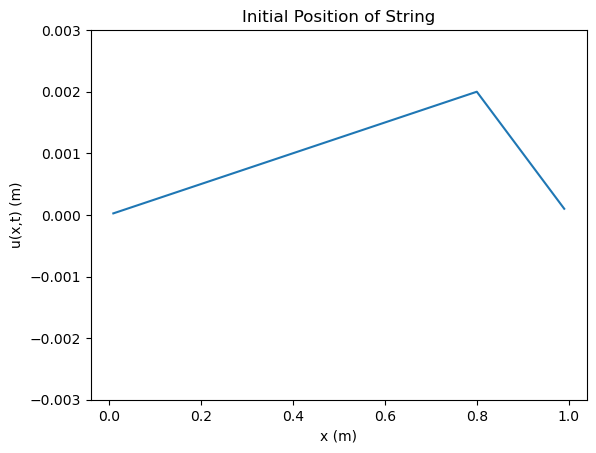

In [162]:
#plots
x = np.linspace(a, b, n+1)[1:-1]
plt.plot(x, history[0])
plt.ylim(-(pull_l+0.5*pull_l), (pull_l+0.5*pull_l))
plt.xlabel('x (m)')
plt.ylabel('u(x,t) (m)')
plt.title('Initial Position of String')
plt.show()

In [163]:
#animation plot
def plot_gif(history, dt, n, filename='wave.gif'):
    x = np.linspace(0, 1, n+1)[1:-1]  
    
    print(f'x shape: {x.shape}')
    print(f'history[0] shape: {history[0].shape}')
    
    fig, ax = plt.subplots()
    line, = ax.plot(x, history[0])
    ax.set_ylim(-0.005, 0.005)
    ax.set_xlim(0, 1)
    ax.set_xlabel('x')
    ax.set_ylabel('u')
    
    frames = history[::2]
    
    def update(i):
        line.set_ydata(frames[i])
        ax.set_title(f'frame {i}')
        return line,
    
    ani = animation.FuncAnimation(
        fig, update,
        frames=len(frames),
        interval=50
    )
    
    ani.save(filename, writer='pillow', fps=30)
    plt.close()
    print(f'saved to {filename}')

n_actual = history[0].shape[0] + 1
plot_gif(history, dt, n_actual)


x shape: (99,)
history[0] shape: (99,)
saved to wave.gif


#### Analytical Solution

$$u(x,t) = \sum_{n=1}^{\infty} B_n sin(\frac{n\pi x}{L})cos(\frac{n\pi ct}{L})e^{-\frac{c_d}{2\rho A}t}$$
where the Fourier Coefficents 
$$B_n = \frac{2L^2h}{n^2\pi^2x_p (L-x_p)}sin(\frac{n\pi x_p}{L})$$

In [164]:
#analytical solver
def analytical_solution(x, t, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier):
    u = np.zeros_like(x)
    L = b-a
    c = np.sqrt(tension_0/(density*area))
    for n in range(1,num_fourier+1):
        Bn = ((2*L**2*pull_l)/(n**2 * np.pi**2 * pluck_d * (L - pluck_d)))*np.sin((n * np.pi * pluck_d )/ L)
        sum_entry = Bn * np.sin((n*np.pi*x)/L)*np.cos((n*np.pi*c*t)/L)*np.exp(-c_d*t/(2*density*area))
        u += sum_entry
    return u


In [165]:
#analytical solve, usign values defined above

#constants of interest
num_fourier = 50

#variables of interest
x_analytical = np.linspace(a, b, 101)
u_analytical = analytical_solution(x, t, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)



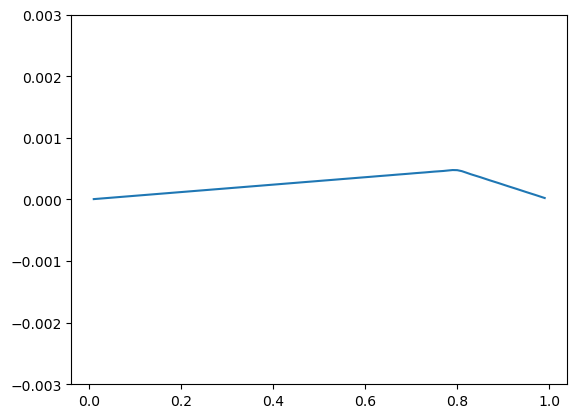

In [166]:
#initial plot test
plt.plot(x, u_analytical)
plt.ylim(-(pull_l+0.5*pull_l), (pull_l+0.5*pull_l))
plt.show()

In [167]:
#animation for analytical solution
def plot_analytical_gif(dt, density, area, tension_0, c_d, a, b, pull_l, pluck_d, num_fourier, filename='analytical.gif'):
    x_fine = np.linspace(a, b, 400)
    t_end = (10*(b-a))/np.sqrt(tension_0/(density*area))
    times = np.arange(0, t_end, dt)
    frames = times[::2]

    fig, ax = plt.subplots(figsize=(9, 4))
    u0 = analytical_solution(x_fine, 0, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)
    line, = ax.plot(x_fine, u0, 'r-', lw=2)
    ax.axhline(0, color='b', lw=0.5, ls='--', alpha=0.3)
    ax.set_xlim(a, b)
    ax.set_ylim(-pull_l*1.5, pull_l*1.5)
    ax.set_xlabel('x (m)')
    ax.set_ylabel('u (m)')
    ax.grid(True, alpha=0.3)

    def update(i):
        t_val = frames[i]
        u = analytical_solution(x_fine, t_val, c_d, density, area, tension_0, a, b, pull_l, pluck_d, num_fourier)
        line.set_ydata(u)
        ax.set_title(f'Analytical  —  t = {t_val*1000:.1f} ms ')
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(frames), interval=20)
    ani.save(filename, writer='pillow', fps=50)
    plt.close()
    print(f'saved to {filename}')

plot_analytical_gif(dt, density, area, tension_0, c_d, a, b, pull_l, pluck_d, num_fourier)

saved to analytical.gif
